![Architecture of LeNet-5](figures/LeNet-5_Figure.png "LeNet-5")

### Environment Setup

In [250]:
%matplotlib inline
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm

from statistics import mean
import numpy as np
import random
import time

### Data Loading & Normalization

In [2]:
def load_dataset(root='../cnn_scratch_nieNazwa/data', transform=transforms.ToTensor()):
    train_set = torchvision.datasets.CIFAR10(root=root, train=True, transform=transform, download=True)
    val_set = torchvision.datasets.CIFAR10(root=root, train=False, transform=transform, download=True)
    return train_set, val_set

In [3]:
train_data, val_data = load_dataset()

100.0%


In [6]:
len(train_data), len(train_data[0]), train_data[0][0].shape

(50000, 2, torch.Size([3, 32, 32]))

In [7]:
len(val_data), len(val_data[0]), val_data[0][0].shape

(10000, 2, torch.Size([3, 32, 32]))

In [8]:
def Stats_PerChannel(data, get=False):
    imgs = torch.stack([img for img, _ in data])
    
    min_vals = imgs.amin(dim=(0, 2, 3))
    max_vals = imgs.amax(dim=(0, 2, 3))
    print(f"Min vals: {min_vals}\tMax vals: {max_vals}\n")
    
    means = torch.mean(imgs, dim=(0, 2, 3))
    stds = torch.std(imgs, dim=(0, 2, 3))
    print(f"Mean: {means}\tStd: {stds}")

    if get:
        m = tuple(round(x, 5) for x in means.tolist())
        s = tuple(round(x, 5) for x in stds.tolist())
        return m, s

In [9]:
norm_mean, norm_std = Stats_PerChannel(train_data, get=True)

Min vals: tensor([0., 0., 0.])	Max vals: tensor([1., 1., 1.])

Mean: tensor([0.4914, 0.4822, 0.4465])	Std: tensor([0.2470, 0.2435, 0.2616])


In [10]:
norm_mean, norm_std

((0.4914, 0.48216, 0.44653), (0.24703, 0.24349, 0.26159))

In [11]:
train_data, val_data = load_dataset(transform=transforms.Compose([transforms.ToTensor(),
     transforms.Normalize(norm_mean, norm_std)]))

In [12]:
Stats_PerChannel(train_data)

Min vals: tensor([-1.9892, -1.9802, -1.7070])	Max vals: tensor([2.0589, 2.1267, 2.1158])

Mean: tensor([-1.2720e-06, -6.4988e-06,  3.4809e-06])	Std: tensor([1.0000, 1.0000, 1.0000])


In [13]:
torch.tensor(norm_mean)

tensor([0.4914, 0.4822, 0.4465])

### Visualizing the dataset

In [14]:
classes = {0: 'plane', 1: 'car', 2: 'bird', 3: 'cat', 4: 'deer', 
           5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

In [15]:
def imshow(img, lbl, m, s):
    mean, std = torch.tensor(m), torch.tensor(s)
    
    img = img * std[:, None, None] + mean[:, None, None]   
    img.clamp_(0, 1)
    
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(lbl)

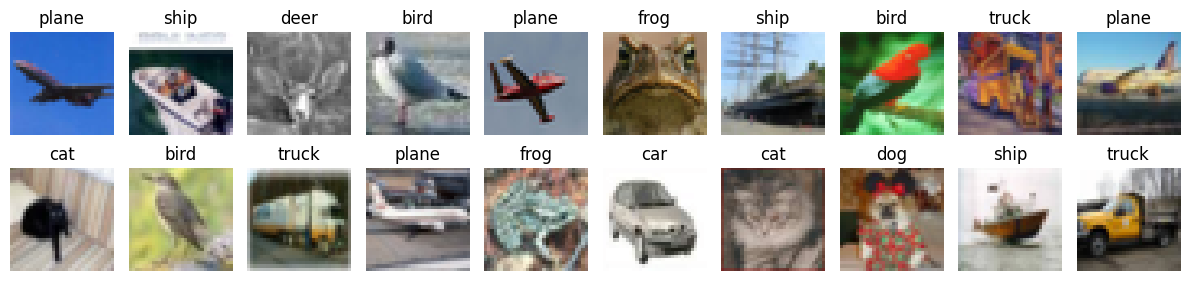

In [168]:
rand_idx = random.sample(range(0, len(train_data)), 20)

figure = plt.figure(figsize=(12, 3), tight_layout=True)

for i, idx  in enumerate(rand_idx):
    img, label = train_data[idx]
    figure.add_subplot(2, 10, i+1)
    imshow(img, classes[label], norm_mean, norm_std)
plt.show()

## Architecture

<center>
  <img src="figures/LeNet-5_Figure.png" width="750">
</center>

### Cross-Coorelation

#### Since LeNet does not implement padding and stride above 1 in any convolutional layer we may calculate output shape by simple formula:
- #### Number of Filters, (Input_height - Kernel_height + 1), (Input_width - Kernel_width + 1) - do poprawy

## Pack That shit in The class !!!!!

### I didn't want to just call nn.Conv2d() and treat it like a black box. This is my "from-scratch" implementation of the LeNet-5 architecture, focusing on the actual tensor logic behind convolutional layers.
#### This is my understanding and method

In [4]:
"""Conv Layer Class"""

'Conv Layer Class'

In [299]:
class PoolLayer(nn.Module):
    def __init__(self, k_size, stride, p_type, device):
        super().__init__()
        self.K_h, self.K_w = k_size
        self.stride = stride
        self.device = device
        
        """ Setting Pooling function """
        if p_type == 'avg':
            self.func = torch.mean
        else:
            self.func = torch.amax

    def forward(self, X):
        X_batch, X_c, X_h, X_w = X.shape[0], X.shape[1], X.shape[2], X.shape[3]
        Y = torch.zeros(X_batch, X_c, (X_h - self.K_h)//self.stride + 1,
                        (X_w - self.K_w)//self.stride + 1, device=self.device)

        for i, i_x in enumerate(range(0, X_h - self.K_h + 1, self.stride)):
            for j, j_x in enumerate(range(0, X_w - self.K_w + 1, self.stride)):
                x_slice = X[:, :, i_x: i_x + self.K_h, j_x: j_x + self.K_w]
                Y[:, :, i, j] = self.func(x_slice, dim=(2, 3))
                
        return Y

In [300]:
class LinearLayer(nn.Module):
    def __init__(self, num_in, num_out):
        super().__init__()

        """ He Kaiming Initialization """
        std = np.sqrt(2.0 / num_in)

        """ Defining Parameters """
        self.W = torch.nn.Parameter(torch.randn(num_in, num_out) * std)
        self.b = torch.nn.Parameter(torch.zeros(num_out))

    def forward(self, X):
        return torch.matmul(X, self.W) + self.b

In [301]:
class ConvLayer(nn.Module):
    def __init__(self, k_size, num_in, num_out, device):
        super().__init__()
        self.K_h, self.K_w = k_size
        self.K_c = num_out
        self.device = device
        
        """ He Kaiming Initialization """
        fan_in = num_in * self.K_h * self.K_w
        std = np.sqrt(2.0 / fan_in)

        """ Defining Parameters """
        self.K = torch.nn.Parameter(
            torch.randn(self.K_c, num_in, self.K_h, self.K_w) * std)
        
        self.b = torch.nn.Parameter(torch.zeros(num_out, 1, 1))

    def forward(self, X):
        X_batch, X_h, X_w = X.shape[0], X.shape[2], X.shape[3]
        Y = torch.zeros(X_batch, self.K_c, X_h - self.K_h + 1, X_w - self.K_w + 1, device=self.device)
        
        for i in range(Y.shape[2]):
            for j in range(Y.shape[3]):
                x_slice = X[:, :, i: i+self.K_h, j: j+self.K_w]         
                Y[:, :, i, j] = (x_slice.unsqueeze(dim=1) * self.K).sum(dim=(2, 3, 4))
                
        return Y + self.b 

In [309]:
class LeNet_5(nn.Module):
    def __init__(self, lr, device):
        super().__init__()
        self.lr = lr
        self.device = device

        self.Conv_1 = ConvLayer(k_size=(5, 5), num_in=3, num_out=6, device=self.device)
        self.Pool_1 = PoolLayer(k_size=(2, 2), stride=2, p_type='avg', device=self.device)
        self.Conv_2 = ConvLayer(k_size=(5, 5), num_in=6, num_out=16, device=self.device)
        self.Pool_2 = PoolLayer(k_size=(2, 2), stride=2, p_type='avg', device=self.device)
        
        self.Linear_1 = LinearLayer(num_in=400, num_out=120)
        self.Linear_2 = LinearLayer(num_in=120, num_out=84)
        self.Linear_3 = LinearLayer(num_in=84, num_out=10)

    def forward(self, X):
        X = self.Pool_1(F.relu(self.Conv_1(X)))
        X = self.Pool_2(F.relu(self.Conv_2(X)))
        X = X.reshape(X.shape[0], -1)
        X = F.relu(self.Linear_2(F.relu(self.Linear_1(X))))
        return self.Linear_3(X)

    def ce_loss(self, Y_hat, Y):
        return F.cross_entropy(Y_hat, Y, reduction='mean')

    def config_optim(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)
        
    def batch_step(self, batch):
        X, y = batch
        X, y = X.to(self.device), y.to(self.device)
        
        Y_hat = self.forward(X)
        l = self.ce_loss(Y_hat, y)
        acc = (Y_hat.argmax(dim=1) == y).float().mean()
        return l, acc.item()

In [303]:
def data_loader(data, is_train, batch_size):
    return torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=is_train, num_workers=2)

In [304]:
class Trainer():
    def __init__(self, num_epochs, batch_size):
        self.num_epochs = num_epochs
        self.batch_size = batch_size

    def plotter_init(self, title):
        self.plotter = Plotter(title)

    def prepare_data(self, train_data, val_data):
        self.train_dataloader = data_loader(train_data, True, self.batch_size)
        self.val_dataloader = data_loader(val_data, False, self.batch_size)
  
    def fit(self, model, train_data, val_data):
        self.prepare_data(train_data, val_data) 
        self.model = model
        self.optim = model.config_optim()
        
        for epoch in range(self.num_epochs):
            self.fit_epoch(epoch+1)

    def fit_epoch(self, n_epoch):
        train_loss, val_loss, val_acc = [], [], []
        self.model.train()
        pbar_train = tqdm(self.train_dataloader, desc=f"Epoch: {n_epoch} [Train]", leave=False)
        
        for batch in pbar_train:
            loss, _ = self.model.batch_step(batch)     
            self.optim.zero_grad()
            loss.backward()
            self.optim.step()
            
            train_loss.append(loss.item())
            pbar_train.set_postfix(loss=f"{loss.item():.4f}")
            
        self.model.eval()
        pbar_val = tqdm(self.val_dataloader, desc=f"Epoch: {n_epoch} [Val]", leave=False)
        
        for batch in pbar_val:
            with torch.no_grad():
                loss, acc = self.model.batch_step(batch)
                
                val_loss.append(loss.item())
                val_acc.append(acc)
                pbar_val.set_postfix(acc=f"{acc:.2f}")
                
        self.plotter.plot(mean(train_loss), mean(val_loss), mean(val_acc))

In [305]:
class Plotter():
    def __init__(self, title):
        self.title = title
        self.train_losses = []
        self.val_losses = []
        self.val_acc = []
        self.epoch = 0

    def update_stats(self, train_loss, val_loss, acc):
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.val_acc.append(acc)
        self.epoch += 1

    def plot(self, train_loss, val_loss, acc):
        self.update_stats(train_loss, val_loss, acc)
        epochs = range(1, self.epoch + 1)
        
        clear_output(wait=True) 
        plt.figure(figsize=(6,4), constrained_layout=True)
        plt.plot(epochs, self.train_losses, label=f"Train loss: {self.train_losses[-1]:.4f}")
        plt.plot(epochs, self.val_losses, label=f"Val loss: {self.val_losses[-1]:.4f}")
        plt.plot(epochs, self.val_acc, linestyle="-.", label=f"Val acc: {self.val_acc[-1]:.4f}")
        plt.xlabel("Epoch")
        plt.title(self.title)
        plt.legend()
        plt.show()

In [306]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [307]:
model = LeNet_5(lr=0.1, device=device)
model.to(device)

LeNet_5(
  (Conv_1): ConvLayer()
  (Pool_1): PoolLayer()
  (Conv_2): ConvLayer()
  (Pool_2): PoolLayer()
  (Linear_1): LinearLayer()
  (Linear_2): LinearLayer()
  (Linear_3): LinearLayer()
)

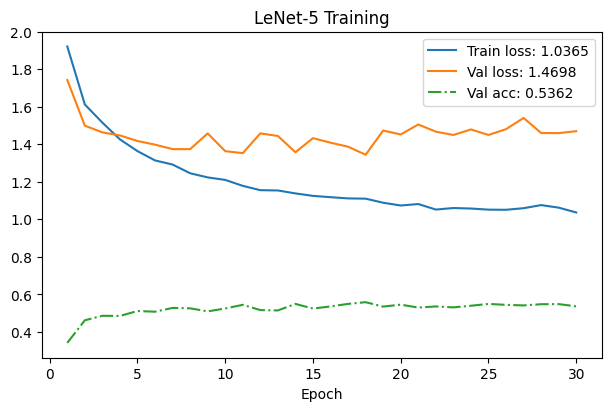

In [308]:
trainer = Trainer(num_epochs=30, batch_size=128)
trainer.plotter_init("LeNet-5 Training")
trainer.fit(model, train_data, val_data)

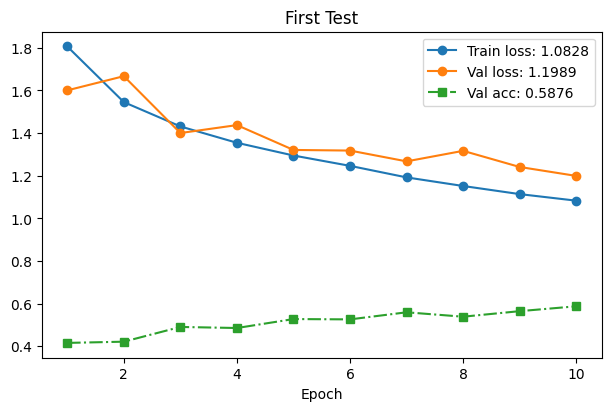

In [273]:
test_trainer.fit(test_model, train_data, val_data)

In [139]:
# model.to('cuda')
# obrazy, etykiety = batch
# obrazy = obrazy.to(device)
# etykiety = etykiety.to(device)

In [141]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [84]:
X, y = next(iter(data_loader(train_data, True, 256)))
X.shape, y.shape

(torch.Size([256, 3, 32, 32]), torch.Size([256]))

In [140]:
y

tensor([8, 8, 2, 2, 8, 9, 2, 5, 6, 6, 0, 2, 4, 5, 9, 1, 7, 6, 3, 6, 8, 5, 3, 0,
        3, 9, 9, 7, 0, 5, 0, 7, 7, 3, 0, 0, 9, 5, 7, 8, 4, 0, 1, 6, 6, 1, 9, 9,
        8, 8, 2, 2, 9, 3, 4, 9, 9, 4, 7, 2, 2, 9, 9, 7, 8, 0, 9, 5, 4, 5, 7, 6,
        0, 3, 9, 8, 9, 6, 2, 6, 9, 7, 1, 6, 0, 8, 3, 9, 8, 8, 8, 0, 0, 5, 6, 6,
        3, 5, 1, 9, 5, 3, 0, 6, 1, 9, 6, 9, 1, 8, 1, 4, 4, 2, 7, 7, 6, 7, 0, 3,
        3, 0, 8, 2, 1, 2, 6, 6, 5, 2, 6, 3, 3, 6, 2, 1, 4, 7, 7, 4, 2, 8, 6, 0,
        2, 5, 1, 8, 3, 4, 5, 1, 2, 4, 8, 0, 8, 1, 2, 5, 9, 8, 7, 7, 3, 7, 2, 8,
        8, 1, 6, 1, 8, 5, 2, 3, 9, 6, 4, 8, 2, 8, 4, 2, 4, 9, 2, 1, 8, 7, 7, 6,
        3, 1, 3, 1, 9, 5, 1, 3, 4, 7, 5, 5, 1, 7, 6, 3, 4, 7, 6, 8, 9, 2, 7, 7,
        6, 2, 3, 4, 8, 1, 6, 7, 0, 9, 9, 9, 0, 9, 4, 0, 6, 5, 5, 7, 9, 1, 5, 2,
        2, 4, 7, 4, 6, 7, 7, 5, 6, 5, 8, 8, 7, 1, 1, 1])

In [81]:
test_flat = torch.ones(5, 4, 3, 3)
test_flat.reshape(test_flat.shape[0], -1).shape

torch.Size([5, 36])

In [85]:
K_test = torch.randn(6, 3, 5, 5)
K_test

tensor([[[[ 1.5504, -2.0225, -0.6721,  1.2130, -2.2791],
          [-0.2175, -0.8179, -0.9191,  0.9328, -0.7798],
          [-0.3588,  0.1466, -0.2303,  0.2343,  0.7532],
          [-0.7762, -1.0667, -0.1344,  0.6126,  0.5239],
          [ 0.1582, -0.4939,  0.3053,  1.5371, -0.9628]],

         [[ 2.2987, -0.1376,  0.4754, -0.9878, -0.9637],
          [ 0.6155, -1.3377, -0.2419,  1.3629,  2.2515],
          [ 0.8166, -0.3723,  0.9888, -0.2623, -0.9976],
          [-0.4093,  1.0587,  0.4902, -0.9832, -0.5469],
          [-0.6435, -1.5605, -0.6943, -0.8696, -0.5680]],

         [[ 0.4759,  1.0523,  0.5749, -1.2280,  0.9138],
          [-0.6459, -0.3353, -1.1786,  0.0996, -0.7671],
          [ 0.5059,  0.6792, -0.6924,  1.4922, -0.2430],
          [-0.9681,  1.6358,  0.7285,  1.3547,  1.7260],
          [ 0.2275, -1.1201, -0.1960, -1.6029, -0.8477]]],


        [[[-1.7485, -0.3337,  0.2358, -0.6138,  0.1882],
          [ 0.0648, -0.0061, -1.0550,  0.5164, -1.1055],
          [ 0.0048,  0.

In [298]:
tic = time.time()
for X, y in data_loader(train_data, True, 256):
    continue
f'{time.time() - tic:.2f} sec'

'11.25 sec'

In [91]:
K_test.shape

torch.Size([6, 3, 5, 5])

In [145]:
for i in range(1, 2):
    print(i)

1


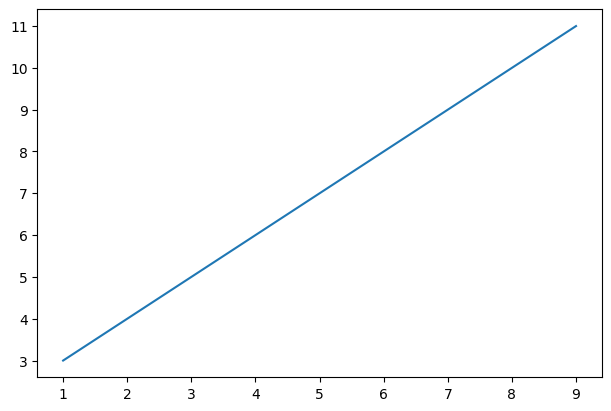

In [165]:
plt.figure(figsize=(6,4), constrained_layout=True)
plt.plot(range(1, 10), [x+2 for x in range(1, 10)])
plt.show()